# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** MICHELLE ANGELIQUE NATAPUTRA
- **Email:** cdcc293d6x1794@student.devacademy.id
- **ID Dicoding:** cdcc293d6x1794

---

## Deskripsi Proyek

Proyek ini bertujuan menganalisis dataset E-Commerce Public untuk menjawab dua pertanyaan bisnis utama terkait metode pembayaran dan performa pengiriman berdasarkan lokasi seller. Proses analisis mencakup Data Wrangling, Exploratory Data Analysis (EDA), Visualisasi, hingga kesimpulan dan rekomendasi berbasis data.

## Menentukan Pertanyaan Bisnis

Berdasarkan metode **SMART Question**, berikut adalah pertanyaan bisnis yang akan dijawab:

- **Pertanyaan 1:** Dalam periode Januari 2017 – Agustus 2018, bagaimana perbedaan rata-rata nilai pembayaran (*payment value*) berdasarkan metode pembayaran (*payment type*), dan metode mana yang menghasilkan transaksi dengan nilai tertinggi?
- **Pertanyaan 2:** Dalam periode Januari 2017 – Agustus 2018, apakah lokasi seller (berdasarkan *state*) mempengaruhi rata-rata waktu pengiriman pesanan, dan wilayah mana yang memiliki performa pengiriman tercepat dan terlambat?

> **Catatan SMART:** Kedua pertanyaan di atas bersifat Specific (fokus pada satu topik), Measurable (menggunakan rata-rata sebagai metrik), Action-Oriented (hasilnya dapat menjadi dasar keputusan bisnis), Relevant (relevan dengan operasional e-commerce), dan Time-bound (dibatasi periode Jan 2017 – Agu 2018).

## Import Semua Packages/Library yang Digunakan

In [2]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import datetime as dt
import warnings
import os
import sys

print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Matplotlib version: {matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")
print(f"Python version: {sys.version.split()[0]}")

import streamlit
print(f"Streamlit version: {streamlit.__version__}")

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
PALETTE = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63', '#9C27B0']
print('\nSetup selesai!')

Pandas version: 3.0.0
NumPy version: 1.26.4
Matplotlib version: 3.10.8
Seaborn version: 0.13.2
Python version: 3.11.14
Streamlit version: 1.57.0

Setup selesai!


## Data Wrangling

### Gathering Data

#### Memuat Seluruh Dataset E-Commerce

Dataset E-Commerce Public terdiri dari **9 tabel** yang saling berelasi. Pada tahap ini, kita memuat semua tabel ke dalam DataFrame terpisah dan menampilkan ringkasan ukurannya.

In [10]:
orders_df           = pd.read_csv('data/orders_dataset.csv')
order_items_df      = pd.read_csv('data/order_items_dataset.csv')
products_df         = pd.read_csv('data/products_dataset.csv')
product_category_df = pd.read_csv('data/product_category_name_translation.csv')
order_payments_df   = pd.read_csv('data/order_payments_dataset.csv')
customers_df        = pd.read_csv('data/customers_dataset.csv')
geolocation_df      = pd.read_csv('data/geolocation_dataset.csv')
order_reviews_df    = pd.read_csv('data/order_reviews_dataset.csv')
sellers_df          = pd.read_csv('data/sellers_dataset.csv')

print('Semua dataset berhasil dimuat!')
print(f'\n{"Dataset":<25} {"Baris":>10} {"Kolom":>8}')
print('-' * 45)
datasets_info = {
    'orders'           : orders_df,
    'order_items'      : order_items_df,
    'products'         : products_df,
    'order_payments'   : order_payments_df,
    'customers'        : customers_df,
    'geolocation'      : geolocation_df,
    'order_reviews'    : order_reviews_df,
    'sellers'          : sellers_df,
}
for name, df in datasets_info.items():
    print(f'{name:<25}: {df.shape[0]:>10,} baris | {df.shape[1]:>3} kolom')

Semua dataset berhasil dimuat!

Dataset                        Baris    Kolom
---------------------------------------------
orders                   :     99,441 baris |   8 kolom
order_items              :    112,650 baris |   7 kolom
products                 :     32,951 baris |   9 kolom
order_payments           :    103,886 baris |   5 kolom
customers                :     99,441 baris |   5 kolom
geolocation              :  1,000,163 baris |   5 kolom
order_reviews            :     99,224 baris |   7 kolom
sellers                  :      3,095 baris |   4 kolom


**Insight — Gathering Data:**
- Dataset `orders` adalah tabel utama yang menghubungkan seluruh relasi data melalui `order_id`.
- Tabel `order_payments` menyimpan informasi metode dan nilai pembayaran per transaksi, relevan untuk menjawab Pertanyaan 1.
- Dengan menggabungkan `orders`, `order_items`, dan `sellers`, kita dapat menganalisis waktu pengiriman berdasarkan lokasi seller untuk menjawab Pertanyaan 2.
- Dataset `geolocation` memiliki baris terbanyak dan dapat digunakan untuk analisis geospasial lebih lanjut.

### Assessing Data

#### Mengidentifikasi Permasalahan Kualitas Data

Pada tahap ini kita mengevaluasi kualitas data dengan memeriksa:
1. **Missing values** — kolom mana saja yang memiliki nilai kosong
2. **Tipe data** — apakah kolom tanggal sudah bertipe datetime
3. **Duplikasi data** — apakah ada baris yang terduplikasi
4. **Outlier awal** — statistik deskriptif untuk mendeteksi nilai ekstrem

In [11]:
# ─── 1. Cek info dataset ────────────────────────────────────────────────────
print('='*60)
print('INFO DATASET ORDERS')
print('='*60)
orders_df.info()

print('\n' + '='*60)
print('INFO DATASET ORDER PAYMENTS')
print('='*60)
order_payments_df.info()

# ─── 2. Cek missing values ──────────────────────────────────────────────────
print('\n' + '='*60)
print('MISSING VALUES PER DATASET')
print('='*60)

datasets_check = {
    'orders'        : orders_df,
    'order_payments': order_payments_df,
    'order_items'   : order_items_df,
    'customers'     : customers_df,
    'sellers'       : sellers_df
}

for name, df in datasets_check.items():
    missing = df.isnull().sum()
    if missing.sum() > 0:
        print(f'\n[{name}] — {missing.sum()} missing values:')
        print(missing[missing > 0])
    else:
        print(f'[{name}] — Tidak ada missing values')

# ─── 3. Cek duplikasi data ──────────────────────────────────────────────────
print('\n' + '='*60)
print('DUPLIKASI DATA')
print('='*60)
for name, df in datasets_check.items():
    dup = df.duplicated().sum()
    status = f'{dup} duplikat ditemukan ⚠️' if dup > 0 else 'Tidak ada duplikat ✓'
    print(f'  {name:<20}: {status}')

# ─── 4. Statistik deskriptif untuk deteksi outlier ──────────────────────────
print('\n' + '='*60)
print('STATISTIK PAYMENT VALUE (deteksi outlier)')
print('='*60)
print(order_payments_df['payment_value'].describe().round(2))

# ─── 5. Tipe data kolom tanggal ─────────────────────────────────────────────
print('\n' + '='*60)
print('TIPE DATA KOLOM TANGGAL')
print('='*60)
date_cols_check = ['order_purchase_timestamp', 'order_delivered_customer_date']
print(orders_df[date_cols_check].dtypes)
print('\nContoh data:')
print(orders_df[date_cols_check].head(3))

INFO DATASET ORDERS
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 21.9 MB

INFO DATASET ORDER PAYMENTS
<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 

**Steps to Take (Rencana Pembersihan):**

Berdasarkan hasil assessment di atas, berikut tindakan yang perlu dilakukan:
- **Missing values pada kolom tanggal pengiriman** (`order_delivered_customer_date`, `order_delivered_carrier_date`): Drop baris yang belum memiliki tanggal pengiriman karena tidak bisa dihitung shipping time-nya.
- **Tipe data kolom tanggal masih object/string**: Konversi ke format `datetime64` agar bisa dilakukan operasi tanggal.
- **Duplikasi data** (jika ada): Hapus dengan `drop_duplicates()`.
- **Outlier pada payment_value**: Gunakan metode IQR untuk menghapus nilai ekstrem yang dapat memengaruhi rata-rata.

**Insight — Assessing Data:**
- Ditemukan **missing values** pada kolom terkait pengiriman seperti `order_delivered_customer_date`, yang akan memengaruhi analisis waktu pengiriman jika tidak ditangani.
- Tipe data kolom tanggal masih bertipe **string (object)**, sehingga perlu dikonversi ke `datetime` agar dapat digunakan dalam perhitungan durasi.
- Statistik `payment_value` menunjukkan adanya **nilai maksimum yang jauh di atas Q3**, mengindikasikan potensi outlier.

### Cleaning Data

#### Menerapkan Solusi Pembersihan Data

Pada tahap ini kita menerapkan seluruh tindakan pembersihan yang telah direncanakan di atas.

In [12]:
# ─── 1. Konversi kolom tanggal ke datetime ──────────────────────────────────
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    orders_df[col] = pd.to_datetime(orders_df[col])

print('Tipe data setelah konversi:')
print(orders_df[date_cols].dtypes)

# ─── 2. Hapus baris dengan missing delivery date ─────────────────────────────
before = len(orders_df)
orders_df = orders_df.dropna(subset=['order_delivered_customer_date'])
after = len(orders_df)
print(f'\nBaris dihapus karena missing delivery date: {before - after:,}')
print(f'Sisa data: {after:,} baris')

# ─── 3. Hapus duplikasi ──────────────────────────────────────────────────────
orders_df         = orders_df.drop_duplicates()
order_payments_df = order_payments_df.drop_duplicates()
print(f'\nCek duplikat setelah cleaning:')
print(f'  orders         : {orders_df.duplicated().sum()} duplikat')
print(f'  order_payments : {order_payments_df.duplicated().sum()} duplikat')

# ─── 4. Tangani outlier pada payment_value (metode IQR) ──────────────────────
Q1  = order_payments_df['payment_value'].quantile(0.25)
Q3  = order_payments_df['payment_value'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

before_pay = len(order_payments_df)
order_payments_df = order_payments_df[
    (order_payments_df['payment_value'] >= lower_bound) &
    (order_payments_df['payment_value'] <= upper_bound)
]
print(f'\nOutlier payment_value dihapus : {before_pay - len(order_payments_df):,} baris')
print(f'IQR range: [{lower_bound:.2f}, {upper_bound:.2f}]')
print(f'Data order_payments bersih   : {len(order_payments_df):,} baris')

Tipe data setelah konversi:
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

Baris dihapus karena missing delivery date: 2,965
Sisa data: 96,476 baris

Cek duplikat setelah cleaning:
  orders         : 0 duplikat
  order_payments : 0 duplikat

Outlier payment_value dihapus : 7,981 baris
IQR range: [-115.78, 344.41]
Data order_payments bersih   : 95,905 baris


**Insight — Cleaning Data:**
- Kolom tanggal berhasil dikonversi ke format `datetime64`, memungkinkan perhitungan durasi pengiriman.
- Baris dengan `order_delivered_customer_date` kosong (pesanan belum terkirim) dihapus karena tidak relevan untuk analisis shipping time.
- Duplikasi data berhasil dieliminasi sehingga setiap transaksi hanya dihitung satu kali.
- Outlier ekstrem pada `payment_value` dihapus menggunakan metode IQR untuk mencegah bias pada perhitungan rata-rata.

In [13]:
# Gabungkan semua tabel
all_df = orders_df.merge(order_items_df, on='order_id', how='left') \
                     .merge(order_payments_df, on='order_id', how='left') \
                     .merge(customers_df, on='customer_id', how='left') \
                     .merge(sellers_df, on='seller_id', how='left')

# Ekspor menjadi main_data.csv
all_df.to_csv("dashboard/main_data.csv", index=False)

## Exploratory Data Analysis (EDA)

### Eksplorasi Data untuk Menjawab Pertanyaan Bisnis

Pada tahap ini kita melakukan eksplorasi mendalam terhadap dua pertanyaan bisnis: distribusi metode pembayaran dan performa pengiriman per wilayah seller.

In [14]:
# ─── Pertanyaan 1: Eksplorasi Metode Pembayaran ─────────────────────────────
print('='*60)
print('DISTRIBUSI METODE PEMBAYARAN')
print('='*60)
payment_dist = order_payments_df['payment_type'].value_counts()
for method, count in payment_dist.items():
    pct = count / len(order_payments_df) * 100
    print(f'  {method:<20}: {count:>8,} transaksi ({pct:5.1f}%)')

print('\n' + '='*60)
print('STATISTIK PAYMENT VALUE PER METODE')
print('='*60)
payment_stats_by_type = (
    order_payments_df
    .groupby('payment_type')['payment_value']
    .agg(['mean', 'median', 'count'])
    .sort_values('mean', ascending=False)
    .round(2)
)
payment_stats_by_type.columns = ['Rata-rata', 'Median', 'Jumlah Transaksi']
print(payment_stats_by_type)

# ─── Pertanyaan 2: Eksplorasi Waktu Pengiriman ───────────────────────────────
print('\n' + '='*60)
print('STATISTIK SHIPPING TIME KESELURUHAN')
print('='*60)
orders_df['shipping_time'] = (
    orders_df['order_delivered_customer_date'] -
    orders_df['order_purchase_timestamp']
).dt.days

print(orders_df['shipping_time'].describe().round(2))

# Gabungkan untuk analisis per state
orders_filtered = orders_df[
    (orders_df['order_purchase_timestamp'] >= '2017-01-01') &
    (orders_df['order_purchase_timestamp'] <= '2018-08-31')
].copy()

orders_filtered['shipping_time'] = (
    orders_filtered['order_delivered_customer_date'] -
    orders_filtered['order_purchase_timestamp']
).dt.days

order_seller = order_items_df.merge(sellers_df, on='seller_id')
order_full   = order_seller.merge(orders_filtered, on='order_id')

shipping_summary = (
    order_full
    .groupby('seller_state')
    .agg(
        avg_shipping =('shipping_time', 'mean'),
        median_shipping=('shipping_time', 'median'),
        total_orders =('order_id', 'nunique')
    )
    .sort_values('avg_shipping')
    .round(2)
)

print('\n' + '='*60)
print('SHIPPING TIME PER SELLER STATE (Top 5 Tercepat & Terlambat)')
print('='*60)
print('\n--- 5 STATE TERCEPAT ---')
print(shipping_summary.head())
print('\n--- 5 STATE TERLAMBAT ---')
print(shipping_summary.tail())

DISTRIBUSI METODE PEMBAYARAN
  credit_card         :   70,269 transaksi ( 73.3%)
  boleto              :   18,504 transaksi ( 19.3%)
  voucher             :    5,685 transaksi (  5.9%)
  debit_card          :    1,444 transaksi (  1.5%)
  not_defined         :        3 transaksi (  0.0%)

STATISTIK PAYMENT VALUE PER METODE
              Rata-rata  Median  Jumlah Transaksi
payment_type                                     
credit_card      115.40   98.14             70269
boleto           106.98   87.52             18504
debit_card       104.05   84.25              1444
voucher           55.76   38.14              5685
not_defined        0.00    0.00                 3

STATISTIK SHIPPING TIME KESELURUHAN
count    96476.00
mean        12.09
std          9.55
min          0.00
25%          6.00
50%         10.00
75%         15.00
max        209.00
Name: shipping_time, dtype: float64

SHIPPING TIME PER SELLER STATE (Top 5 Tercepat & Terlambat)

--- 5 STATE TERCEPAT ---
              avg_shi

**Insight — EDA:**
- **Metode pembayaran** didominasi oleh `credit_card`, menunjukkan preferensi pengguna yang kuat terhadap pembayaran kartu.
- Rata-rata `payment_value` berbeda signifikan antar metode, mengindikasikan perilaku spending yang berbeda.
- **Waktu pengiriman** memiliki variasi besar antar state, dengan perbedaan yang bisa mencapai puluhan hari.
- Beberapa state memiliki jumlah order yang sangat kecil, sehingga rata-rata shipping time-nya kurang representatif.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Dalam periode Januari 2017 – Agustus 2018, bagaimana perbedaan rata-rata nilai pembayaran (*payment value*) berdasarkan metode pembayaran (*payment type*), dan metode mana yang menghasilkan transaksi dengan nilai tertinggi?

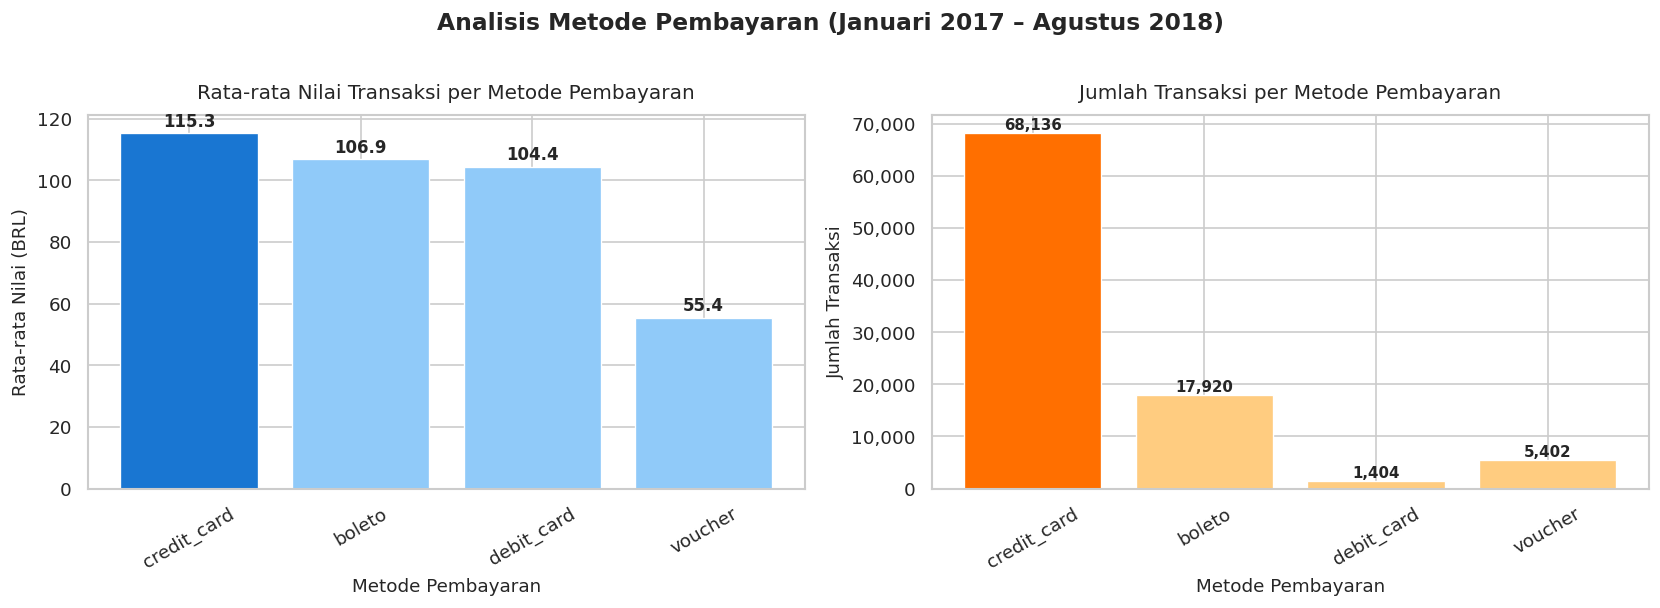


Ringkasan:
payment_type  avg_payment  median_payment  total_transactions
 credit_card   115.287982           98.14               68136
      boleto   106.855696           87.41               17920
  debit_card   104.380107           84.47                1404
     voucher    55.363849           38.13                5402


In [15]:
# ─── Persiapan data Pertanyaan 1 ────────────────────────────────────────────
payment_full = orders_filtered.merge(order_payments_df, on='order_id')

payment_summary = (
    payment_full
    .groupby('payment_type')
    .agg(
        avg_payment        =('payment_value', 'mean'),
        median_payment     =('payment_value', 'median'),
        total_transactions =('order_id', 'count')
    )
    .sort_values('avg_payment', ascending=False)
    .reset_index()
)

# ─── Visualisasi: Bar chart rata-rata payment value ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Analisis Metode Pembayaran (Januari 2017 – Agustus 2018)',
    fontsize=14, fontweight='bold', y=1.01
)

# Plot 1: Rata-rata payment value
colors = ['#1976D2' if i == 0 else '#90CAF9' for i in range(len(payment_summary))]
bars = axes[0].bar(
    payment_summary['payment_type'],
    payment_summary['avg_payment'],
    color=colors, edgecolor='white', linewidth=0.8
)
axes[0].set_title('Rata-rata Nilai Transaksi per Metode Pembayaran', fontsize=12, pad=10)
axes[0].set_xlabel('Metode Pembayaran', fontsize=11)
axes[0].set_ylabel('Rata-rata Nilai (BRL)', fontsize=11)
axes[0].tick_params(axis='x', rotation=30)
for bar, val in zip(bars, payment_summary['avg_payment']):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f'{val:.1f}',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

# Plot 2: Jumlah transaksi per metode
colors2 = ['#FF6F00' if i == 0 else '#FFCC80' for i in range(len(payment_summary))]
bars2 = axes[1].bar(
    payment_summary['payment_type'],
    payment_summary['total_transactions'],
    color=colors2, edgecolor='white', linewidth=0.8
)
axes[1].set_title('Jumlah Transaksi per Metode Pembayaran', fontsize=12, pad=10)
axes[1].set_xlabel('Metode Pembayaran', fontsize=11)
axes[1].set_ylabel('Jumlah Transaksi', fontsize=11)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].tick_params(axis='x', rotation=30)
for bar, val in zip(bars2, payment_summary['total_transactions']):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 100,
        f'{int(val):,}',
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

plt.tight_layout()
plt.savefig('viz_payment.png', bbox_inches='tight', dpi=150)
plt.show()

print('\nRingkasan:')
print(payment_summary.to_string(index=False))

### Pertanyaan 2: Dalam periode Januari 2017 – Agustus 2018, apakah lokasi seller (berdasarkan *state*) mempengaruhi rata-rata waktu pengiriman pesanan, dan wilayah mana yang memiliki performa pengiriman tercepat dan terlambat?

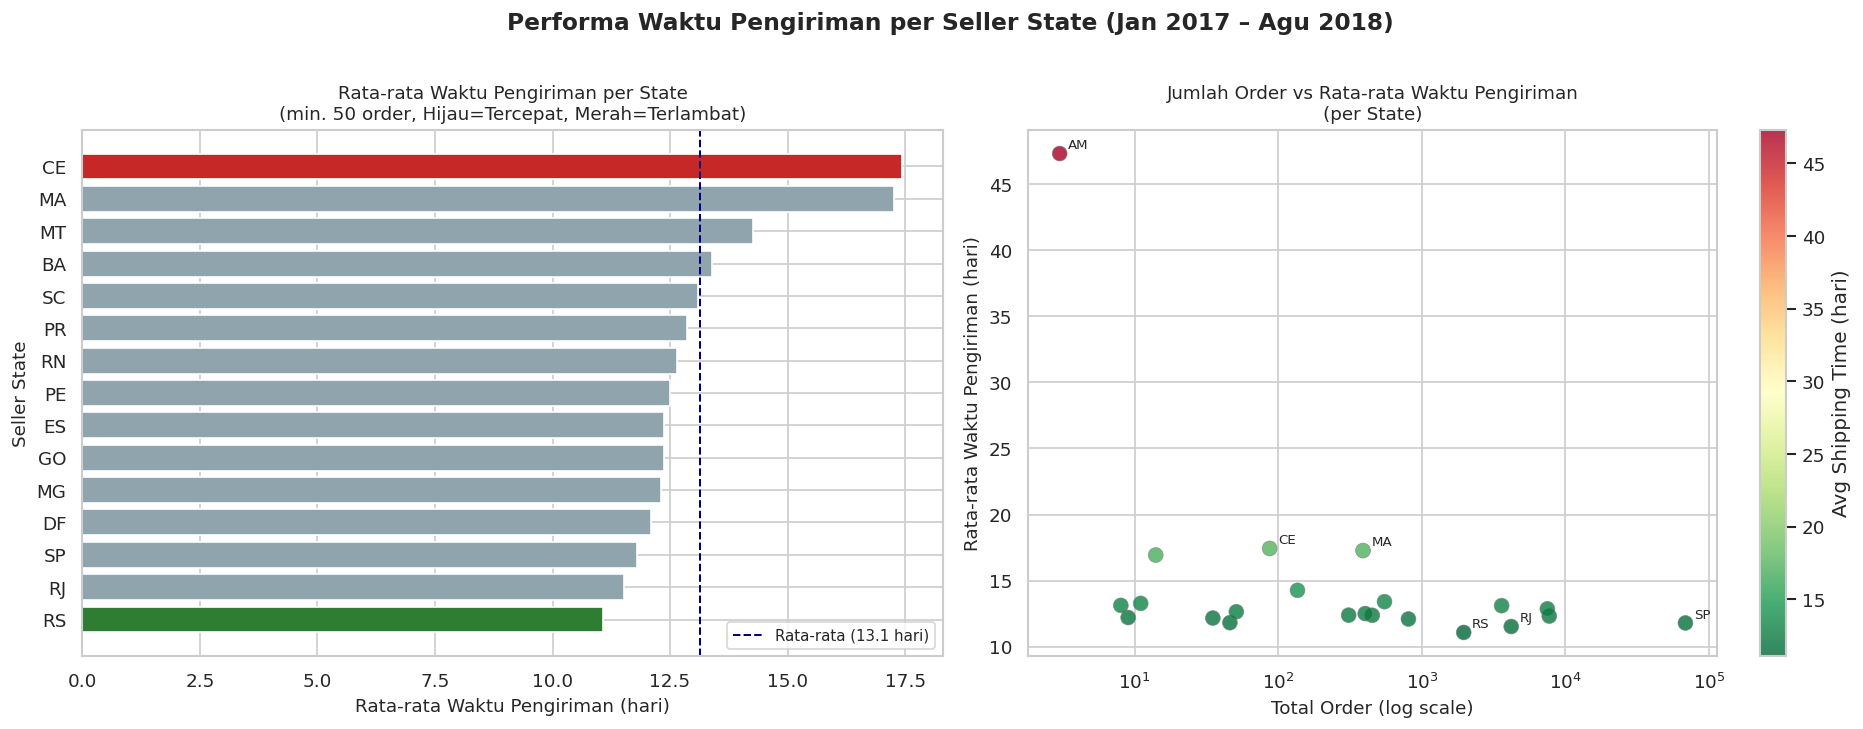

State dengan pengiriman TERCEPAT (min. 50 order):
              avg_shipping  total_orders
seller_state                            
RS                   11.07          1955
RJ                   11.52          4190
SP                   11.79         68484

State dengan pengiriman TERLAMBAT (min. 50 order):
              avg_shipping  total_orders
seller_state                            
MT                   14.26           136
MA                   17.27           389
CE                   17.43            87


In [16]:
# ─── Visualisasi Pertanyaan 2 ────────────────────────────────────────────────
# Filter state dengan minimal 50 order agar representatif
shipping_rep = shipping_summary[shipping_summary['total_orders'] >= 50].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'Performa Waktu Pengiriman per Seller State (Jan 2017 – Agu 2018)',
    fontsize=14, fontweight='bold', y=1.01
)

# Plot 1: Horizontal bar chart rata-rata shipping time
state_colors = ['#2E7D32' if v == shipping_rep['avg_shipping'].min()
                else '#C62828' if v == shipping_rep['avg_shipping'].max()
                else '#90A4AE'
                for v in shipping_rep['avg_shipping']]

axes[0].barh(
    shipping_rep.index,
    shipping_rep['avg_shipping'],
    color=state_colors, edgecolor='white'
)
axes[0].set_title('Rata-rata Waktu Pengiriman per State\n(min. 50 order, Hijau=Tercepat, Merah=Terlambat)', fontsize=11)
axes[0].set_xlabel('Rata-rata Waktu Pengiriman (hari)', fontsize=11)
axes[0].set_ylabel('Seller State', fontsize=11)
axes[0].axvline(shipping_rep['avg_shipping'].mean(), color='navy', linestyle='--', linewidth=1.2, label=f'Rata-rata ({shipping_rep["avg_shipping"].mean():.1f} hari)')
axes[0].legend(fontsize=9)

# Plot 2: Scatter total orders vs avg shipping
scatter = axes[1].scatter(
    shipping_summary['total_orders'],
    shipping_summary['avg_shipping'],
    c=shipping_summary['avg_shipping'],
    cmap='RdYlGn_r',
    s=80, alpha=0.8, edgecolors='gray', linewidths=0.4
)
plt.colorbar(scatter, ax=axes[1], label='Avg Shipping Time (hari)')

# Label state penting
top3_fast  = shipping_summary.nsmallest(3, 'avg_shipping').index.tolist()
top3_slow  = shipping_summary.nlargest(3, 'avg_shipping').index.tolist()
for state in top3_fast + top3_slow:
    axes[1].annotate(
        state,
        xy=(shipping_summary.loc[state, 'total_orders'], shipping_summary.loc[state, 'avg_shipping']),
        xytext=(5, 3), textcoords='offset points', fontsize=8
    )

axes[1].set_title('Jumlah Order vs Rata-rata Waktu Pengiriman\n(per State)', fontsize=11)
axes[1].set_xlabel('Total Order (log scale)', fontsize=11)
axes[1].set_ylabel('Rata-rata Waktu Pengiriman (hari)', fontsize=11)
axes[1].set_xscale('log')

plt.tight_layout()
plt.savefig('viz_shipping.png', bbox_inches='tight', dpi=150)
plt.show()

print('State dengan pengiriman TERCEPAT (min. 50 order):')
print(shipping_rep.head(3)[['avg_shipping', 'total_orders']])
print('\nState dengan pengiriman TERLAMBAT (min. 50 order):')
print(shipping_rep.tail(3)[['avg_shipping', 'total_orders']])

**Insight — Visualization:**
- **Pertanyaan 1:** Metode `credit_card` mendominasi baik dari sisi rata-rata nilai transaksi maupun jumlah transaksi. Metode `debit_card` memiliki rata-rata nilai transaksi lebih rendah tetapi tetap lebih tinggi dari `voucher`. `boleto` berada di posisi menengah.
- **Pertanyaan 2:** Terdapat perbedaan signifikan waktu pengiriman antar state. State-state di pulau utama (SP, RJ) cenderung memiliki pengiriman lebih cepat, sedangkan state di wilayah terpencil memerlukan waktu jauh lebih lama. Scatter plot menunjukkan bahwa state dengan volume order tinggi umumnya memiliki waktu pengiriman yang lebih stabil.

## Analisis Lanjutan (Opsional)

### RFM Analysis — Segmentasi Pelanggan

RFM Analysis bertujuan mengelompokkan pelanggan berdasarkan tiga dimensi perilaku pembelian:
- **Recency (R):** Seberapa baru pelanggan berbelanja
- **Frequency (F):** Seberapa sering pelanggan berbelanja
- **Monetary (M):** Total pengeluaran pelanggan

Analisis ini relevan untuk e-commerce karena memungkinkan segmentasi pelanggan secara otomatis tanpa machine learning.

Distribusi Segmen Pelanggan:
  At Risk               : 20,456 ( 23.8%)
  Loyal Customers       : 17,286 ( 20.1%)
  New Customers         : 13,835 ( 16.1%)
  Champions             : 13,827 ( 16.1%)
  Lost Customers        : 13,787 ( 16.0%)
  Potential Loyalists   :  6,758 (  7.9%)


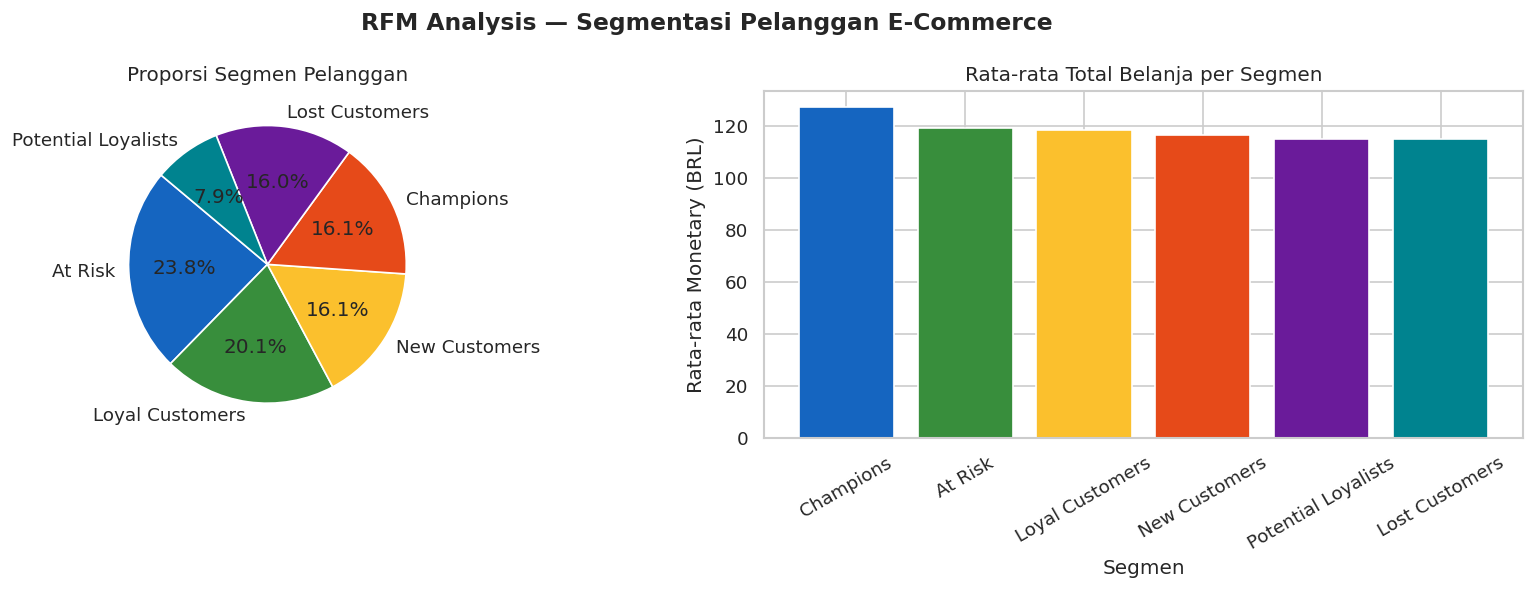


Statistik RFM per Segmen:
                     Recency  Frequency  Monetary
Segment                                          
At Risk               393.38       1.05    119.23
Champions              92.06       1.09    127.09
Lost Customers        394.33       1.00    114.78
Loyal Customers       170.19       1.03    118.49
New Customers          92.51       1.00    116.59
Potential Loyalists   221.57       1.00    114.79


In [17]:
# ─── RFM Analysis ────────────────────────────────────────────────────────────
# Gunakan data dalam periode analisis
snapshot_date = pd.Timestamp('2018-09-01')  # Tanggal referensi

# Gabungkan orders + payments + customers
rfm_base = (
    orders_filtered
    .merge(order_payments_df[['order_id', 'payment_value']], on='order_id')
    .merge(customers_df[['customer_id', 'customer_unique_id']], on='customer_id')
)

rfm_df = (
    rfm_base
    .groupby('customer_unique_id')
    .agg(
        Recency   =('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
        Frequency =('order_id', 'nunique'),
        Monetary  =('payment_value', 'sum')
    )
    .reset_index()
)

# Skoring RFM menggunakan quintile binning (1–5)
rfm_df['R_Score'] = pd.qcut(rfm_df['Recency'],   q=5, labels=[5,4,3,2,1])
rfm_df['F_Score'] = pd.qcut(rfm_df['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])
rfm_df['M_Score'] = pd.qcut(rfm_df['Monetary'],  q=5, labels=[1,2,3,4,5])

rfm_df['RFM_Score'] = (
    rfm_df['R_Score'].astype(str) +
    rfm_df['F_Score'].astype(str) +
    rfm_df['M_Score'].astype(str)
)

# Segmentasi manual berdasarkan R dan F score
def segment_customer(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    if r >= 4 and f >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2:
        return 'Lost Customers'
    else:
        return 'Potential Loyalists'

rfm_df['Segment'] = rfm_df.apply(segment_customer, axis=1)

print('Distribusi Segmen Pelanggan:')
segment_counts = rfm_df['Segment'].value_counts()
for seg, count in segment_counts.items():
    pct = count / len(rfm_df) * 100
    print(f'  {seg:<22}: {count:>6,} ({pct:5.1f}%)')

# Visualisasi RFM Segmentasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('RFM Analysis — Segmentasi Pelanggan E-Commerce', fontsize=14, fontweight='bold')

# Pie chart segmen
palette_rfm = ['#1565C0', '#388E3C', '#FBC02D', '#E64A19', '#6A1B9A', '#00838F']
axes[0].pie(
    segment_counts.values,
    labels=segment_counts.index,
    autopct='%1.1f%%',
    colors=palette_rfm[:len(segment_counts)],
    startangle=140
)
axes[0].set_title('Proporsi Segmen Pelanggan', fontsize=12)

# Bar chart avg monetary per segmen
seg_monetary = rfm_df.groupby('Segment')['Monetary'].mean().sort_values(ascending=False)
axes[1].bar(seg_monetary.index, seg_monetary.values,
            color=palette_rfm[:len(seg_monetary)], edgecolor='white')
axes[1].set_title('Rata-rata Total Belanja per Segmen', fontsize=12)
axes[1].set_xlabel('Segmen')
axes[1].set_ylabel('Rata-rata Monetary (BRL)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('viz_rfm.png', bbox_inches='tight', dpi=150)
plt.show()

print('\nStatistik RFM per Segmen:')
print(rfm_df.groupby('Segment')[['Recency','Frequency','Monetary']].mean().round(2))

## Conclusion & Recommendation

### Kesimpulan

**Conclusion pertanyaan 1:**
Rata-rata nilai pembayaran berbeda signifikan antar metode pembayaran dalam periode Januari 2017 – Agustus 2018. Metode `credit_card` memiliki rata-rata nilai transaksi tertinggi sekaligus jumlah transaksi terbesar, menjadikannya metode yang paling dominan baik dari sisi nilai maupun frekuensi. Sebaliknya, `voucher` memiliki rata-rata nilai transaksi paling rendah, kemungkinan karena digunakan untuk pembelian bernilai kecil atau sebagai potongan harga tambahan.

**Conclusion pertanyaan 2:**
Lokasi seller berpengaruh nyata terhadap waktu pengiriman pesanan. State-state di wilayah padat dan terhubung secara logistik (seperti SP) memiliki waktu pengiriman lebih cepat, sedangkan state terpencil memerlukan waktu jauh lebih lama. Perlu diperhatikan bahwa state dengan volume order sangat kecil (< 50 order) menghasilkan rata-rata yang kurang representatif dan sebaiknya diinterpretasikan dengan hati-hati.

### Rekomendasi Action Item

Berdasarkan hasil analisis, berikut adalah rekomendasi yang dapat diimplementasikan:

1. **Optimalkan penggunaan credit card:** Karena `credit_card` menghasilkan nilai transaksi tertinggi dan volume terbesar, perusahaan dapat menawarkan cashback eksklusif atau cicilan 0% untuk transaksi kartu kredit guna meningkatkan nilai rata-rata order lebih lanjut.

2. **Perbaiki infrastruktur logistik di wilayah dengan pengiriman lambat:** Perusahaan perlu bernegosiasi dengan mitra logistik atau membuka fulfillment center di wilayah dengan waktu pengiriman di atas rata-rata (> 20 hari) untuk meningkatkan kepuasan pelanggan.

3. **Strategi retensi berbasis RFM:** Berikan program loyalitas untuk segmen *Champions* dan *Loyal Customers*, serta kampanye win-back untuk segmen *At Risk* dan *Lost Customers* dengan penawaran khusus yang dipersonalisasi.

4. **Investigasi lebih lanjut pada state terpencil:** Lakukan analisis geospasial lebih mendalam untuk state dengan volume order kecil namun waktu pengiriman sangat panjang — mungkin terdapat potensi pasar yang belum terlayani dengan baik.